Клиент-сервер:
N=10: 7500.0 c
N=100: 50000.0 c
N=1000: 500000.0 c

P2P:

u=0.3 Мбит/с
N=10: 7500.0 c
N=100: 25000.0 c
N=1000: 45454.5 c

u=0.7 Мбит/с
N=10: 7500.0 c
N=100: 15000.0 c
N=1000: 20547.9 c

u=2.0 Мбит/с
N=10: 7500.0 c
N=100: 7500.0 c
N=1000: 7500.0 c


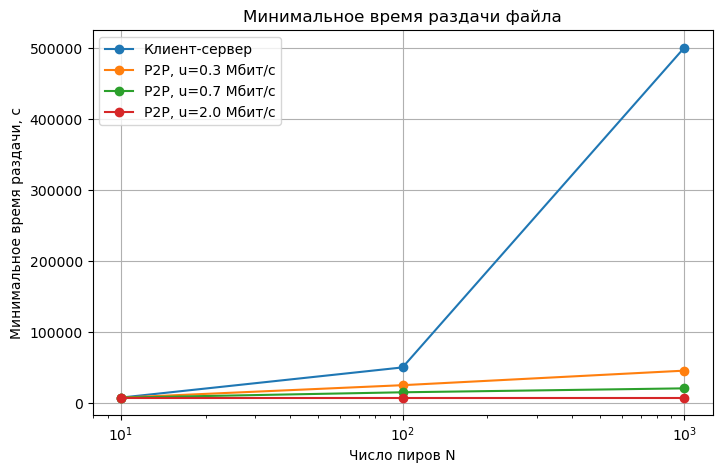

In [2]:
import numpy as np
import matplotlib.pyplot as plt

F = 15_000
u_s = 30
d_i = 2

N_values = np.array([10, 100, 1000])
u_values = [0.3, 0.7, 2.0]

def T_cs(N):
    return max(N * F / u_s, F / d_i)

def T_p2p(N, u):
    return max(F / u_s, F / d_i, N * F / (u_s + N * u))

Tcs_vals = [T_cs(N) for N in N_values]
Tp2p_vals = {u: [T_p2p(N, u) for N in N_values] for u in u_values}

print("Клиент-сервер:")
for N, t in zip(N_values, Tcs_vals):
    print(f"N={N}: {t:.1f} c")

print("\nP2P:")
for u in u_values:
    print(f"\nu={u} Мбит/с")
    for N, t in zip(N_values, Tp2p_vals[u]):
        print(f"N={N}: {t:.1f} c")

plt.figure(figsize=(8, 5))

plt.plot(N_values, Tcs_vals, marker='o', label='Клиент-сервер')

for u in u_values:
    plt.plot(N_values, Tp2p_vals[u], marker='o', label=f'P2P, u={u} Мбит/с')

plt.xscale('log')
plt.xlabel('Число пиров N')
plt.ylabel('Минимальное время раздачи, с')
plt.title('Минимальное время раздачи файла')
plt.grid(True)
plt.legend()
plt.show()